# Machine Learning Anomaly Detection Models Comparison

This notebook compares three different machine learning approaches for anomaly detection:
1. **Isolation Forest** - Unsupervised ensemble method
2. **AutoEncoder** - Deep learning unsupervised method
3. **SVM (Support Vector Machine)** - Supervised method

We'll use the `is_anomaly` column from the processed logs as ground truth to evaluate model performance.


## Setup Instructions

**Important:** Make sure you're using the virtual environment kernel for this notebook.

### Option 1: Use the registered kernel (Recommended)
1. In Jupyter Notebook/Lab, go to **Kernel → Change Kernel → Python (AI Anomaly Dashboard)**
2. This kernel uses the virtual environment with all packages installed

### Option 2: Start Jupyter from the virtual environment
1. Activate the virtual environment:
   ```bash
   cd /Users/joandume/Documents/PROJECTS_FOLDER/AI_Anomaly_Dashboard
   source venv/bin/activate
   ```

2. Start Jupyter:
   ```bash
   jupyter notebook
   # or
   jupyter lab
   ```

### All required packages are installed in the virtual environment:
- pandas, numpy, matplotlib, seaborn
- scikit-learn
- tensorflow
- jupyter, ipykernel

**Note:** If you see import errors, make sure you've selected the correct kernel (Python (AI Anomaly Dashboard)) from the Kernel menu.


In [1]:
# Verify all required packages are installed
import sys
import os

# Check if we're using the virtual environment
venv_path = '/Users/joandume/Documents/PROJECTS_FOLDER/AI_Anomaly_Dashboard/venv'
in_venv = venv_path in sys.executable or 'venv' in sys.executable

print(f"Python executable: {sys.executable}")
if in_venv:
    print("✓ Using virtual environment")
else:
    print("⚠️  Not using virtual environment - packages may not be found!")
    print("   Please select kernel: Kernel → Change Kernel → Python (AI Anomaly Dashboard)")

print("\n" + "="*60)

required_packages = {
    'pandas': 'pandas',
    'numpy': 'numpy',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn',
    'sklearn': 'scikit-learn',
    'tensorflow': 'tensorflow'
}

missing_packages = []
for module_name, package_name in required_packages.items():
    try:
        __import__(module_name)
        print(f"✓ {package_name} is installed")
    except ImportError:
        print(f"✗ {package_name} is NOT installed")
        missing_packages.append(package_name)

print("="*60)

if missing_packages:
    print(f"\n⚠️  Missing packages: {', '.join(missing_packages)}")
    print("\nTo fix this:")
    print("1. Make sure you've selected the correct kernel:")
    print("   Kernel → Change Kernel → Python (AI Anomaly Dashboard)")
    print("\n2. Or install packages in the virtual environment:")
    print("   source venv/bin/activate")
    print("   pip install " + " ".join(missing_packages))
else:
    print("\n✅ All required packages are installed!")
    print(f"Python version: {sys.version.split()[0]}")


Python executable: /Users/joandume/Documents/PROJECTS_FOLDER/AI_Anomaly_Dashboard/venv/bin/python
✓ Using virtual environment

✓ pandas is installed
✓ numpy is installed
✓ matplotlib is installed
✓ seaborn is installed
✓ scikit-learn is installed
✓ tensorflow is installed

✅ All required packages are installed!
Python version: 3.13.2


## 1. Import Required Libraries


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import IsolationForest
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score, roc_auc_score, roc_curve
)
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


## 2. Load and Explore Data


In [3]:
# Load the processed data
df = pd.read_csv('zt_logs_with_time_diff_and_anomaly.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst few rows:")
df.head()


Dataset shape: (35000, 15)

Columns: ['timestamp', 'user', 'role', 'device_id', 'device_trust', 'country', 'lat', 'lon', 'resource', 'action', 'result', 'mfa', 'is_anomaly', 'time_diff_seconds', 'time_diff_minutes']

First few rows:


,timestamp,user,role,device_id,device_trust,country,lat,lon,resource,action,result,mfa,is_anomaly,time_diff_seconds,time_diff_minutes
0,2025-10-10 03:35:18,user001,contractor,device022,untrusted,US,37.77,-122.41,email,login,success,False,0,NaN,NaN
1,2025-10-10 12:58:46,user001,employee,device071,trusted,UK,51.50,-0.12,vpn,access,success,True,0,33808.0,563.466667
2,2025-10-10 12:58:49,user001,employee,device016,trusted,UK,51.50,-0.12,hr_portal,logout,success,True,0,3.0,0.050000
3,2025-10-10 12:59:01,user001,employee,device074,trusted,SG,1.35,103.82,finance_app,access,success,False,1,12.0,0.200000
4,2025-10-10 13:12:38,user001,employee,device007,trusted,US,37.77,-122.41,email,access,success,True,1,817.0,13.616667


In [4]:
# Check data info and anomaly distribution
print("Dataset Info:")
print(df.info())
print("\n" + "="*50)
print("\nAnomaly Distribution:")
print(df['is_anomaly'].value_counts())
print(f"\nAnomaly Percentage: {df['is_anomaly'].mean()*100:.2f}%")
print(f"Normal Percentage: {(1-df['is_anomaly'].mean())*100:.2f}%")


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35000 entries, 0 to 34999
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   timestamp          35000 non-null  object 
 1   user               35000 non-null  object 
 2   role               35000 non-null  object 
 3   device_id          35000 non-null  object 
 4   device_trust       35000 non-null  object 
 5   country            35000 non-null  object 
 6   lat                35000 non-null  float64
 7   lon                35000 non-null  float64
 8   resource           35000 non-null  object 
 9   action             35000 non-null  object 
 10  result             35000 non-null  object 
 11  mfa                35000 non-null  bool   
 12  is_anomaly         35000 non-null  int64  
 13  time_diff_seconds  34950 non-null  float64
 14  time_diff_minutes  34950 non-null  float64
dtypes: bool(1), float64(4), int64(1), object(9)
memory usage

## 3. Feature Engineering


In [5]:
# Create a copy for feature engineering
df_features = df.copy()

# Parse timestamp if it's a string
if df_features['timestamp'].dtype == 'object':
    df_features['timestamp'] = pd.to_datetime(df_features['timestamp'], errors='coerce')

# Extract time-based features
df_features['hour'] = df_features['timestamp'].dt.hour
df_features['day_of_week'] = df_features['timestamp'].dt.dayofweek
df_features['is_weekend'] = (df_features['day_of_week'] >= 5).astype(int)

# Encode categorical variables
categorical_cols = ['role', 'device_trust', 'country', 'resource', 'action', 'result', 'mfa']
label_encoders = {}

for col in categorical_cols:
    if col in df_features.columns:
        le = LabelEncoder()
        df_features[col + '_encoded'] = le.fit_transform(df_features[col].astype(str))
        label_encoders[col] = le

# Handle missing values in time_diff columns
df_features['time_diff_seconds'] = df_features['time_diff_seconds'].fillna(0)
df_features['time_diff_minutes'] = df_features['time_diff_minutes'].fillna(0)

# Create additional features
df_features['has_time_diff'] = (df_features['time_diff_seconds'] > 0).astype(int)
df_features['rapid_time_diff'] = (df_features['time_diff_minutes'] < 180).astype(int)

print("Feature engineering completed!")
print(f"New shape: {df_features.shape}")


Feature engineering completed!
New shape: (35000, 27)


## 4. Prepare Features and Target


In [6]:
# Select features for modeling
# Exclude non-numeric and target columns
exclude_cols = ['timestamp', 'user', 'device_id', 'is_anomaly'] + categorical_cols

# Get numeric columns
feature_cols = [col for col in df_features.columns 
                if col not in exclude_cols and df_features[col].dtype in [np.int64, np.float64]]

print(f"Selected {len(feature_cols)} features:")
print(feature_cols)

# Create feature matrix and target
X = df_features[feature_cols].copy()
y = df_features['is_anomaly'].copy()

# Handle any remaining NaN values
X = X.fillna(0)

print(f"\nFeature matrix shape: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")


Selected 14 features:
['lat', 'lon', 'time_diff_seconds', 'time_diff_minutes', 'is_weekend', 'role_encoded', 'device_trust_encoded', 'country_encoded', 'resource_encoded', 'action_encoded', 'result_encoded', 'mfa_encoded', 'has_time_diff', 'rapid_time_diff']

Feature matrix shape: (35000, 14)
Target distribution:
is_anomaly
1    27854
0     7146
Name: count, dtype: int64


In [7]:
# Split data for supervised models (SVM)
# Use 70% for training, 30% for testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nTraining set anomaly rate: {y_train.mean()*100:.2f}%")
print(f"Test set anomaly rate: {y_test.mean()*100:.2f}%")

# Scale features for models that need it
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_scaled = scaler.transform(X)


Training set: 24500 samples
Test set: 10500 samples

Training set anomaly rate: 79.58%
Test set anomaly rate: 79.58%


### ⚠️ Fixed Version - Use This Cell Instead

The previous cell had an error because the anomaly rate (79.58%) exceeds IsolationForest's maximum contamination parameter (50%). This fixed version uses `contamination='auto'` when the anomaly rate is too high.


## 5. Model 1: Isolation Forest

In [11]:
# FIXED VERSION: Isolation Forest with proper contamination handling
# Isolation Forest is an unsupervised method
# It doesn't use labels during training, but we'll evaluate on test set
print("Training Isolation Forest...")

# Use contamination rate based on actual anomaly rate
# Note: IsolationForest contamination must be in range (0.0, 0.5]
# If anomaly rate > 0.5, we use 'auto' to let IsolationForest determine it
actual_anomaly_rate = y.mean()
print(f"Actual anomaly rate in data: {actual_anomaly_rate:.4f} ({actual_anomaly_rate*100:.2f}%)")

if actual_anomaly_rate > 0.5:
    print(f"⚠️  Warning: Anomaly rate ({actual_anomaly_rate*100:.2f}%) exceeds IsolationForest's maximum (50%)")
    print("   Using contamination='auto' - IsolationForest will determine contamination automatically")
    contamination_rate = 'auto'
else:
    contamination_rate = actual_anomaly_rate

print(f"Using contamination rate: {contamination_rate}")

# Train on full dataset (unsupervised)
iso_forest = IsolationForest(
    n_estimators=100,
    contamination=contamination_rate,
    random_state=42,
    n_jobs=-1
)

iso_forest.fit(X_scaled)

# Predict on test set
# Isolation Forest returns -1 for anomalies, 1 for normal
# We need to convert: -1 -> 1 (anomaly), 1 -> 0 (normal)
iso_predictions = iso_forest.predict(X_test_scaled)
iso_predictions_binary = (iso_predictions == -1).astype(int)

print("Isolation Forest training completed!")
print(f"Predicted anomalies: {iso_predictions_binary.sum()} out of {len(iso_predictions_binary)} ({iso_predictions_binary.mean()*100:.2f}%)")


Training Isolation Forest...
Actual anomaly rate in data: 0.7958 (79.58%)
⚠️  Warning: Anomaly rate (79.58%) exceeds IsolationForest's maximum (50%)
   Using contamination='auto' - IsolationForest will determine contamination automatically
Using contamination rate: auto
Isolation Forest training completed!
Predicted anomalies: 5214 out of 10500 (49.66%)


## 6. Model 2: AutoEncoder


In [12]:
# Import TensorFlow/Keras for AutoEncoder
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    from tensorflow.keras.callbacks import EarlyStopping
    
    print("TensorFlow version:", tf.__version__)
    TENSORFLOW_AVAILABLE = True
except ImportError:
    print("TensorFlow not available. Installing...")
    import subprocess
    subprocess.check_call(['pip', 'install', 'tensorflow'])
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    from tensorflow.keras.callbacks import EarlyStopping
    TENSORFLOW_AVAILABLE = True


TensorFlow version: 2.20.0


In [13]:
# Build AutoEncoder model
input_dim = X_train_scaled.shape[1]
encoding_dim = max(8, input_dim // 4)  # Encoding dimension

print(f"Input dimension: {input_dim}")
print(f"Encoding dimension: {encoding_dim}")

# Create autoencoder directly
autoencoder = keras.Sequential([
    # Encoder
    layers.Dense(64, activation='relu', input_shape=(input_dim,)),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(encoding_dim, activation='relu'),
    # Decoder
    layers.Dense(32, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(input_dim, activation='linear')
])

autoencoder.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

print("AutoEncoder architecture:")
autoencoder.summary()


Input dimension: 14
Encoding dimension: 8
AutoEncoder architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 14)             │           910 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,614 (25.84 KB)

 Trainable params: 6,614 (25.84 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Train AutoEncoder on normal data only (unsupervised approach)
# Use only normal samples for training
normal_mask = y_train == 0
X_train_normal = X_train_scaled[normal_mask]

print(f"Training AutoEncoder on {X_train_normal.shape[0]} normal samples...")

# Train the model
history = autoencoder.fit(
    X_train_normal, X_train_normal,
    epochs=50,
    batch_size=256,
    validation_split=0.2,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=1
)

print("AutoEncoder training completed!")


Training AutoEncoder on 5002 normal samples...
Epoch 1/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.6484 - mae: 0.6815 - val_loss: 1.5885 - val_mae: 0.6806
Epoch 2/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.4972 - mae: 0.6876 - val_loss: 1.3714 - val_mae: 0.6804
Epoch 3/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.2970 - mae: 0.6795 - val_loss: 1.0471 - val_mae: 0.6349
Epoch 4/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0770 - mae: 0.6377 - val_loss: 0.8265 - val_mae: 0.5784
Epoch 5/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.9791 - mae: 0.6053 - val_loss: 0.6853 - val_mae: 0.5515
Epoch 6/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8520 - mae: 0.5904 - val_loss: 0.5910 - val_mae: 0.5312
Epoch 7/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.7470 - mae: 0.5691 - val_loss: 0.5562 - val_mae: 0.5174
Epoch 8/50
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.6689 - mae: 0.5600 - val_loss: 0.4858 - val_mae: 0.4950
Epoch 9/50
16/16 ━━━━━━━━

In [15]:
# Predict reconstruction errors on test set
# Higher reconstruction error = more likely to be an anomaly
reconstructions = autoencoder.predict(X_test_scaled, verbose=0)
mse = np.mean(np.power(X_test_scaled - reconstructions, 2), axis=1)

# Use threshold based on normal data reconstruction errors
normal_reconstructions = autoencoder.predict(X_train_scaled[normal_mask], verbose=0)
normal_mse = np.mean(np.power(X_train_scaled[normal_mask] - normal_reconstructions, 2), axis=1)
threshold = np.percentile(normal_mse, 95)  # 95th percentile as threshold

# Predict anomalies
ae_predictions_binary = (mse > threshold).astype(int)

print(f"Reconstruction error threshold: {threshold:.4f}")
print(f"Anomalies detected: {ae_predictions_binary.sum()} out of {len(ae_predictions_binary)}")


Reconstruction error threshold: 0.2598
Anomalies detected: 457 out of 10500


## 7. Model 3: Support Vector Machine (SVM)


In [16]:
# SVM is a supervised method - uses labels during training
print("Training SVM...")

# Use class_weight to handle imbalanced data
svm_model = SVC(
    kernel='rbf',
    probability=True,  # Enable probability estimates for ROC curve
    class_weight='balanced',  # Handle class imbalance
    random_state=42,
    gamma='scale'
)

svm_model.fit(X_train_scaled, y_train)

# Predict on test set
svm_predictions_binary = svm_model.predict(X_test_scaled)
svm_predictions_proba = svm_model.predict_proba(X_test_scaled)[:, 1]

print("SVM training completed!")


Training SVM...
SVM training completed!


## 8. Model Evaluation and Comparison


In [17]:
# Function to evaluate models
def evaluate_model(y_true, y_pred, y_proba=None, model_name="Model"):
    """Evaluate model performance and return metrics"""
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    
    metrics = {
        'Model': model_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    }
    
    # Add ROC-AUC if probability scores available
    if y_proba is not None:
        try:
            roc_auc = roc_auc_score(y_true, y_proba)
            metrics['ROC-AUC'] = roc_auc
        except:
            pass
    
    return metrics

# Evaluate all models
results = []

# Isolation Forest
iso_metrics = evaluate_model(y_test, iso_predictions_binary, model_name="Isolation Forest")
results.append(iso_metrics)

# AutoEncoder
ae_metrics = evaluate_model(y_test, ae_predictions_binary, model_name="AutoEncoder")
results.append(ae_metrics)

# SVM
svm_metrics = evaluate_model(y_test, svm_predictions_binary, svm_predictions_proba, model_name="SVM")
results.append(svm_metrics)

# Create comparison dataframe
results_df = pd.DataFrame(results)
print("\n" + "="*60)
print("MODEL COMPARISON RESULTS")
print("="*60)
print(results_df.to_string(index=False))
print("="*60)



MODEL COMPARISON RESULTS
           Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Isolation Forest  0.498095   0.795934 0.496649  0.611643      NaN
     AutoEncoder  0.223524   0.722101 0.039493  0.074889      NaN
             SVM  0.482381   0.797031 0.469004  0.590522 0.504745


In [18]:
# Detailed classification reports
print("\n" + "="*60)
print("ISOLATION FOREST - Classification Report")
print("="*60)
print(classification_report(y_test, iso_predictions_binary, target_names=['Normal', 'Anomaly']))

print("\n" + "="*60)
print("AUTOENCODER - Classification Report")
print("="*60)
print(classification_report(y_test, ae_predictions_binary, target_names=['Normal', 'Anomaly']))

print("\n" + "="*60)
print("SVM - Classification Report")
print("="*60)
print(classification_report(y_test, svm_predictions_binary, target_names=['Normal', 'Anomaly']))



ISOLATION FOREST - Classification Report
              precision    recall  f1-score   support

      Normal       0.20      0.50      0.29      2144
     Anomaly       0.80      0.50      0.61      8356

    accuracy                           0.50     10500
   macro avg       0.50      0.50      0.45     10500
weighted avg       0.68      0.50      0.55     10500


AUTOENCODER - Classification Report
              precision    recall  f1-score   support

      Normal       0.20      0.94      0.33      2144
     Anomaly       0.72      0.04      0.07      8356

    accuracy                           0.22     10500
   macro avg       0.46      0.49      0.20     10500
weighted avg       0.62      0.22      0.13     10500


SVM - Classification Report
              precision    recall  f1-score   support

      Normal       0.21      0.53      0.30      2144
     Anomaly       0.80      0.47      0.59      8356

    accuracy                           0.48     10500
   macro avg       0

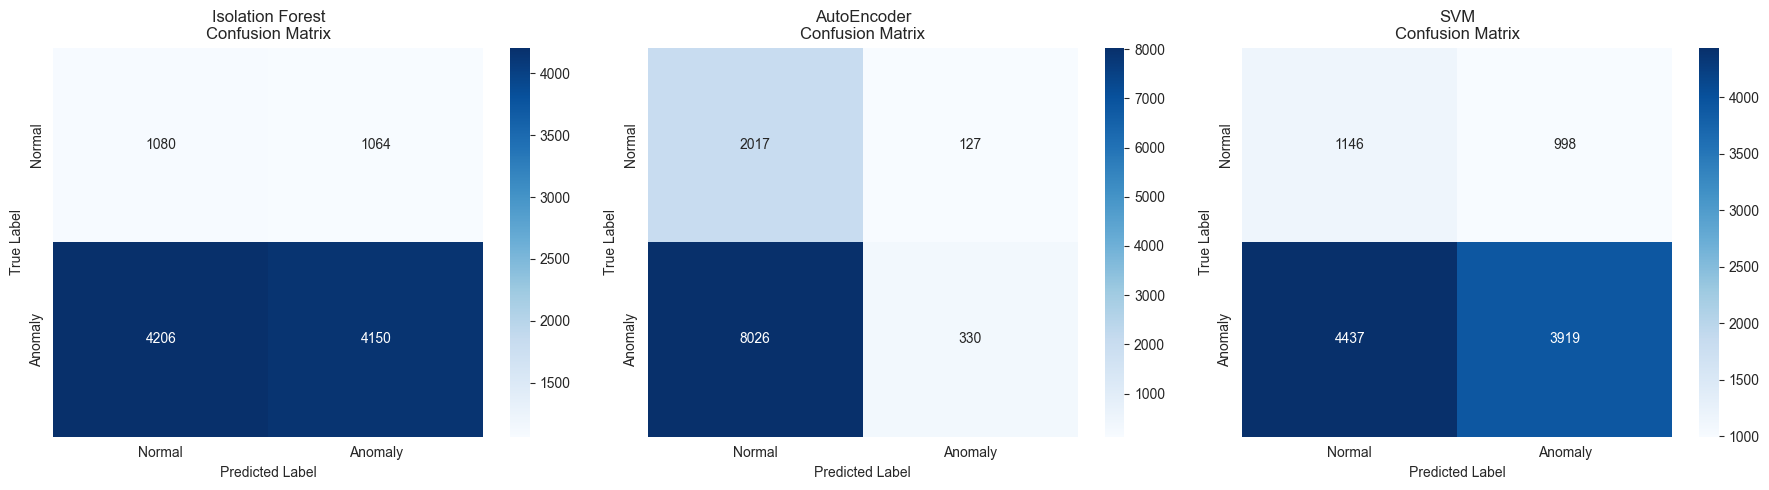

In [19]:
# Confusion Matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = [
    ("Isolation Forest", iso_predictions_binary),
    ("AutoEncoder", ae_predictions_binary),
    ("SVM", svm_predictions_binary)
]

for idx, (name, predictions) in enumerate(models):
    cm = confusion_matrix(y_test, predictions)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Normal', 'Anomaly'],
                yticklabels=['Normal', 'Anomaly'])
    axes[idx].set_title(f'{name}\nConfusion Matrix')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()


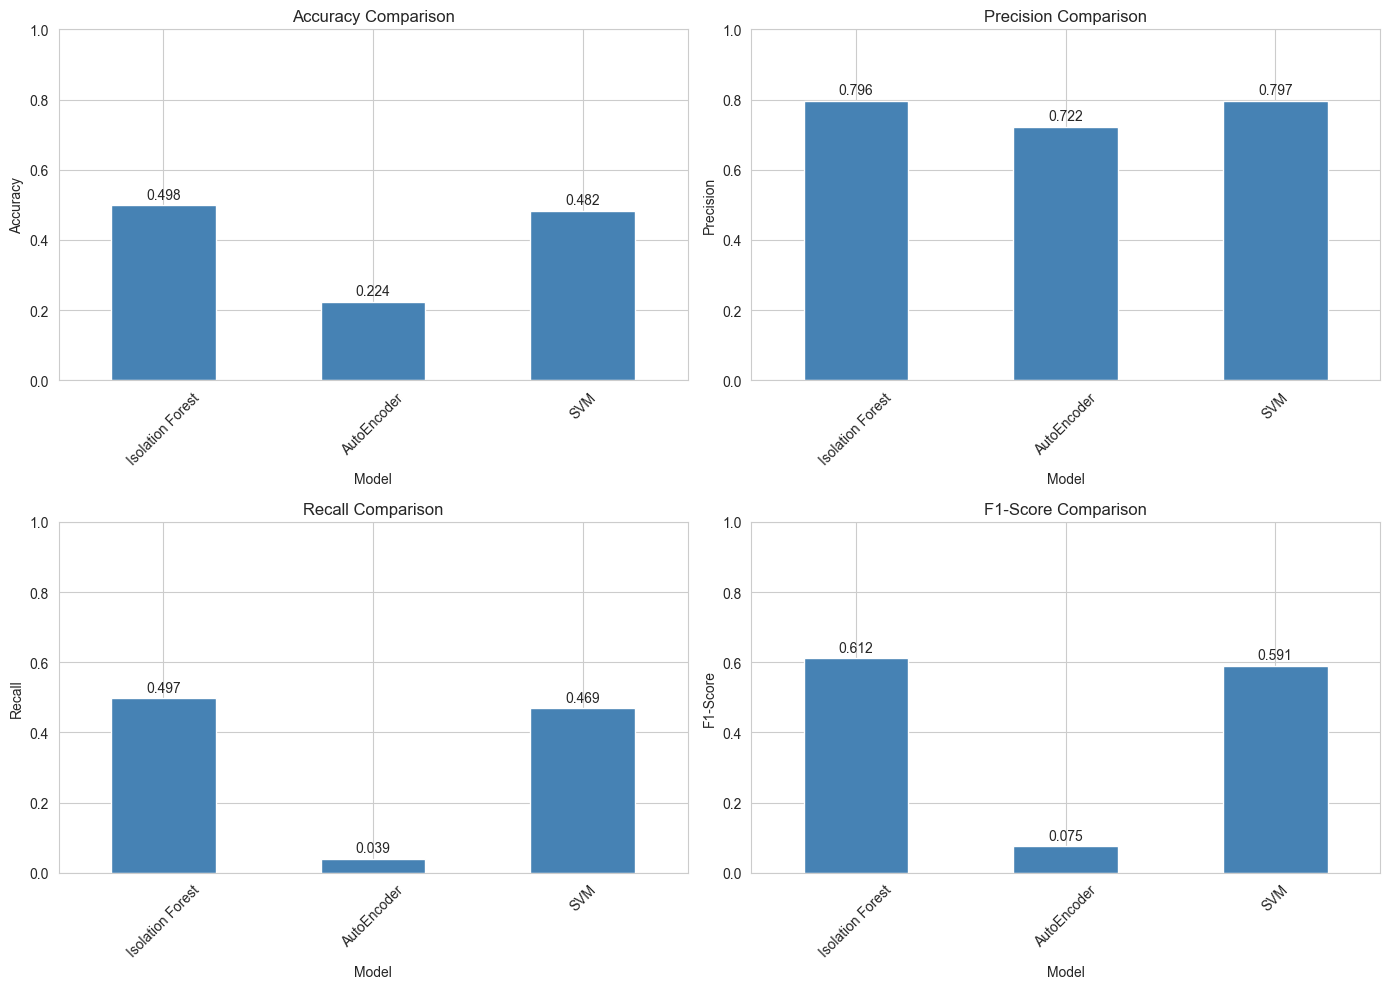

In [20]:
# Visualize metrics comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx // 2, idx % 2]
    results_df.plot(x='Model', y=metric, kind='bar', ax=ax, legend=False, color='steelblue')
    ax.set_title(f'{metric} Comparison')
    ax.set_ylabel(metric)
    ax.set_ylim([0, 1])
    ax.tick_params(axis='x', rotation=45)
    for i, v in enumerate(results_df[metric]):
        ax.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()


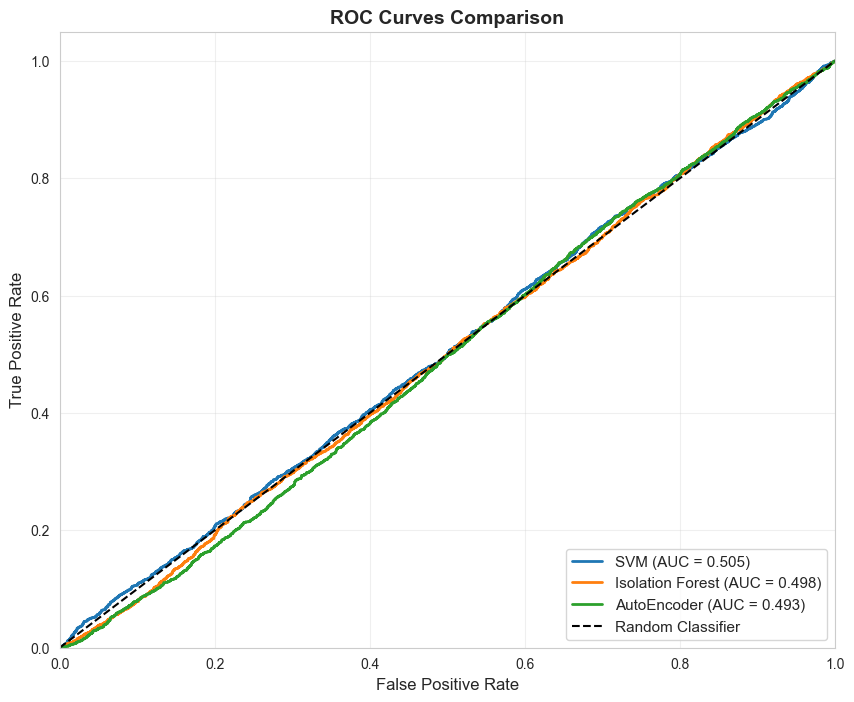

In [21]:
# ROC Curves (for models with probability scores)
plt.figure(figsize=(10, 8))

# SVM ROC Curve
if 'ROC-AUC' in svm_metrics:
    fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_predictions_proba)
    plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {svm_metrics["ROC-AUC"]:.3f})', linewidth=2)

# Isolation Forest - use decision function scores
iso_scores = iso_forest.score_samples(X_test_scaled)
iso_scores_normalized = (iso_scores - iso_scores.min()) / (iso_scores.max() - iso_scores.min())
fpr_iso, tpr_iso, _ = roc_curve(y_test, 1 - iso_scores_normalized)  # Invert: lower score = anomaly
roc_auc_iso = roc_auc_score(y_test, 1 - iso_scores_normalized)
plt.plot(fpr_iso, tpr_iso, label=f'Isolation Forest (AUC = {roc_auc_iso:.3f})', linewidth=2)

# AutoEncoder - use reconstruction errors
fpr_ae, tpr_ae, _ = roc_curve(y_test, mse)
roc_auc_ae = roc_auc_score(y_test, mse)
plt.plot(fpr_ae, tpr_ae, label=f'AutoEncoder (AUC = {roc_auc_ae:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves Comparison', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.show()


## 9. Feature Importance Analysis


Top 15 Features by Correlation with Anomaly:
             Feature  Correlation_with_Anomaly
       has_time_diff                  0.060935
     rapid_time_diff                  0.052784
   time_diff_seconds                  0.039329
   time_diff_minutes                  0.039329
          is_weekend                  0.005312
        role_encoded                  0.003331
                 lon                  0.002726
                 lat                  0.002331
     country_encoded                  0.002088
         mfa_encoded                  0.001919
    resource_encoded                  0.001124
      result_encoded                  0.000902
device_trust_encoded                  0.000739
      action_encoded                  0.000523


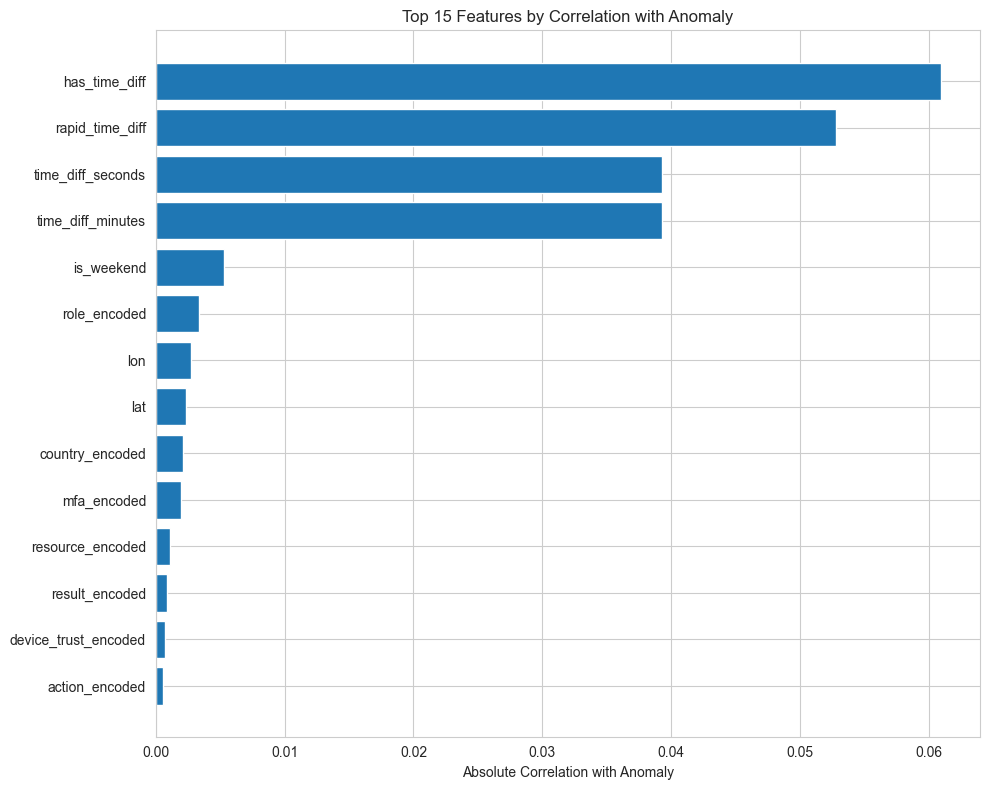

In [22]:
# Analyze feature importance for SVM (using coefficients for linear kernel or feature permutation)
# For RBF kernel, we can use permutation importance or analyze feature correlations with anomalies

# Correlation analysis
feature_importance = pd.DataFrame({
    'Feature': feature_cols,
    'Correlation_with_Anomaly': [abs(X[col].corr(y)) for col in feature_cols]
}).sort_values('Correlation_with_Anomaly', ascending=False)

print("Top 15 Features by Correlation with Anomaly:")
print(feature_importance.head(15).to_string(index=False))

# Visualize top features
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(15)
plt.barh(range(len(top_features)), top_features['Correlation_with_Anomaly'])
plt.yticks(range(len(top_features)), top_features['Feature'])
plt.xlabel('Absolute Correlation with Anomaly')
plt.title('Top 15 Features by Correlation with Anomaly')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## 10. Summary and Conclusions


In [23]:
# Final summary
print("\n" + "="*60)
print("FINAL MODEL COMPARISON SUMMARY")
print("="*60)
print("\nBest Model by Metric:")
print(f"  Accuracy: {results_df.loc[results_df['Accuracy'].idxmax(), 'Model']} ({results_df['Accuracy'].max():.4f})")
print(f"  Precision: {results_df.loc[results_df['Precision'].idxmax(), 'Model']} ({results_df['Precision'].max():.4f})")
print(f"  Recall: {results_df.loc[results_df['Recall'].idxmax(), 'Model']} ({results_df['Recall'].max():.4f})")
print(f"  F1-Score: {results_df.loc[results_df['F1-Score'].idxmax(), 'Model']} ({results_df['F1-Score'].max():.4f})")

if 'ROC-AUC' in results_df.columns:
    print(f"  ROC-AUC: {results_df.loc[results_df['ROC-AUC'].idxmax(), 'Model']} ({results_df['ROC-AUC'].max():.4f})")

print("\n" + "="*60)
print("\nModel Characteristics:")
print("  • Isolation Forest: Unsupervised, fast, good for high-dimensional data")
print("  • AutoEncoder: Unsupervised, deep learning, learns complex patterns")
print("  • SVM: Supervised, robust, good generalization with balanced classes")
print("="*60)



FINAL MODEL COMPARISON SUMMARY

Best Model by Metric:
  Accuracy: Isolation Forest (0.4981)
  Precision: SVM (0.7970)
  Recall: Isolation Forest (0.4966)
  F1-Score: Isolation Forest (0.6116)
  ROC-AUC: SVM (0.5047)


Model Characteristics:
  • Isolation Forest: Unsupervised, fast, good for high-dimensional data
  • AutoEncoder: Unsupervised, deep learning, learns complex patterns
  • SVM: Supervised, robust, good generalization with balanced classes


## 11. Save Best Model (Optional)

You can save the best performing model for future use. Uncomment the code below to save models.


In [24]:
from save_best_models import save_models_from_notebook

# Save all models and results
summary = save_models_from_notebook(
    iso_forest=iso_forest,
    svm_model=svm_model,
    autoencoder=autoencoder,
    scaler=scaler,
    feature_cols=feature_cols,
    results_df=results_df,
    iso_metrics=iso_metrics,
    svm_metrics=svm_metrics,
    ae_metrics=ae_metrics
)

💾 Saving models and results...


   ✓ Isolation Forest saved
   ✓ SVM saved
   ✓ AutoEncoder saved
   ✓ Scaler saved
   ✓ Feature columns saved
   ✓ Comparison results saved
   ✓ Model metrics saved
   ✓ Model summary saved

✅ All models and results saved successfully!

📊 Summary:
   Best Accuracy: Isolation Forest (0.4981)
   Best Precision: SVM (0.7970)
   Best Recall: Isolation Forest (0.4966)
   Best F1-Score: Isolation Forest (0.6116)
   Best ROC-AUC: SVM (0.5047)

🚀 You can now run the Streamlit dashboard:
   streamlit run dashboard.py
